Step1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

Step2. Set Random Seeds For Reproductively

In [2]:
np.random.seed(42)

Step3. load the finance dataset

In [3]:
company=yf.Ticker("AAPL")
data=company.history(period="10y")

#Exactly Only the 'Close' price
close_prices=data[['Close']].copy()
print(f"Data Shape:{close_prices.shape}")
print(f"Date range: {close_prices.index[0].strftime('%Y-%m-%d')} to {close_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"\nFirst 5 rows:\n{close_prices.head()}")
print(f"\nLast 5 Rows:\n{close_prices.tail()}")

Data Shape:(2512, 1)
Date range: 2016-07-08 to 2026-07-07

First 5 rows:
                               Close
Date                                
2016-07-08 00:00:00-04:00  22.009172
2016-07-11 00:00:00-04:00  22.077465
2016-07-12 00:00:00-04:00  22.177628
2016-07-13 00:00:00-04:00  22.052420
2016-07-14 00:00:00-04:00  22.489510

Last 5 Rows:
                                Close
Date                                 
2026-06-30 00:00:00-04:00  289.359985
2026-07-01 00:00:00-04:00  294.380005
2026-07-02 00:00:00-04:00  308.630005
2026-07-06 00:00:00-04:00  312.660004
2026-07-07 00:00:00-04:00  310.660004


Step4. Visualize Close Price

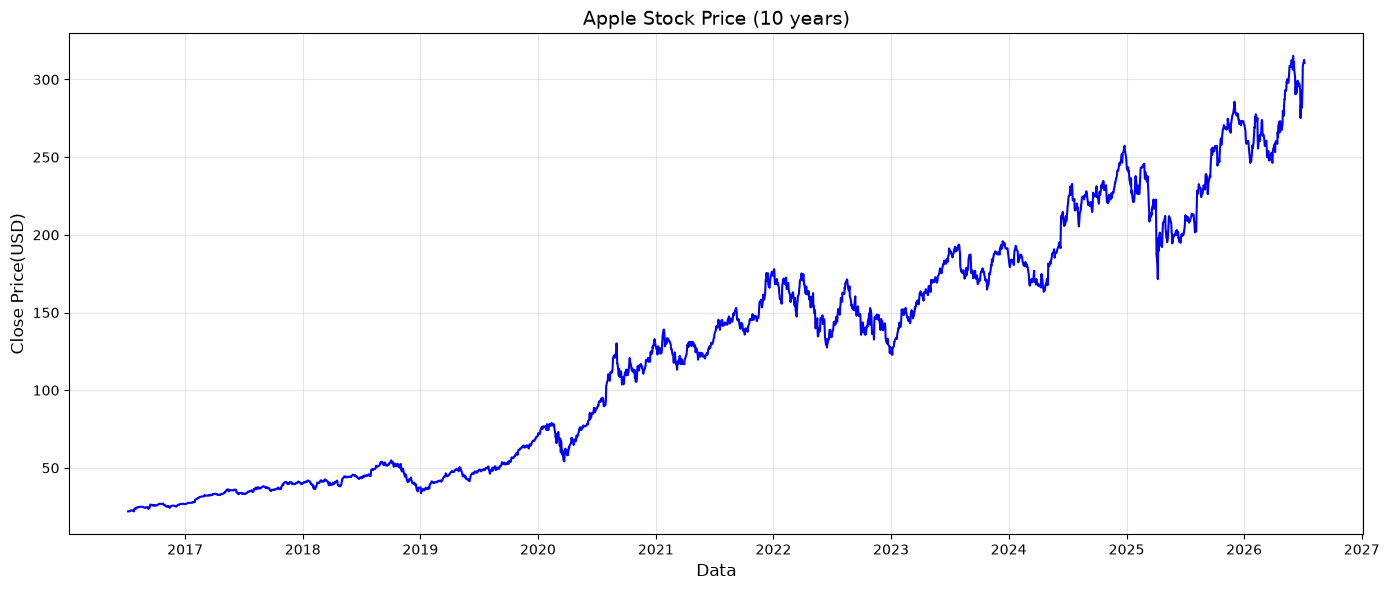

In [4]:
plt.figure(figsize=(14,6))
plt.plot(close_prices.index,close_prices['Close'],color='blue',linewidth=1.5)
plt.title('Apple Stock Price (10 years)',fontsize=14)
plt.xlabel('Data',fontsize=12)
plt.ylabel('Close Price(USD)',fontsize=12)
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

Step5. Data Processing

In [21]:
#Get the close price values
dataset=close_prices['Close'].values.reshape(-1,1)

#Scale the data to [0,1]
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data=scaler.fit_transform(dataset)

#use last 60 days to predicts the next day
look_back=60



Step6. Create The Sequences For RNN

In [22]:
def create_sequences(data,look_back=60):
    # Create sequence for time series prediction
    #look_back=number of previous days to use for prediction
    X,y=[],[]
    for i in range(look_back,len(data)):
        X.append(data[i-look_back:i,0])
        y.append(data[i,0])
    return np.array(X),np.array(y)

#Split data -ensure we have proper test size
total_points=len(scaled_data)
train_size=int(total_points*0.8)

#Critical Fix: Ensure train_size gives enough data for sequence
#We need at least look_back + 50 points for testing
max_test_size=total_points - train_size

if max_test_size<look_back+50:
    train_size=total_points-look_back-50

train_data=scaled_data[:train_size]
test_data=scaled_data[train_size - look_back:]#include ovrelap for sequence creation

print(f"\nTotal Data points: {len(scaled_data)}")
print(f"Training points: {train_size}")
print(f"Test points (including overlap): {len(test_data)}")
print(f"Scaled data range: [{scaled_data.min():.3f}, {scaled_data.max():.3f}]")


#Create Sequences
X_train,y_train=create_sequences(train_data,look_back)
X_test,y_test=create_sequences(test_data,look_back)


#Reshape for RNN input:(sample,time_steps,features)
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"\nX_train shape: {X_train.shape}")
print(f"\ny_train shape: {y_train.shape}")
print(f"\nX_test shape: {X_test.shape}")
print(f"\ny_test shape: {y_test.shape}")

#The test dates correspond to the indices after the training data plus look_back
test_start_idx=train_size#Start from where training data ends
test_end_idx=test_start_idx+len(y_test)#End after all test predictions
test_dates=close_prices.index[test_start_idx:test_end_idx]

print(f"\nTest Dates range:{test_dates[0].strftime('%Y-%m-%d')} to {test_dates[-1].strftime('%Y-%m-%d')}")
print(f"Number of test dates:{len(test_dates)}")
print(f"\ny_test_actual_shape:{y_test.shape}")
print(f"test_dates shape:{test_dates.shape}")



Total Data points: 2512
Training points: 2009
Test points (including overlap): 563
Scaled data range: [0.000, 1.000]

X_train shape: (1949, 60, 1)

y_train shape: (1949,)

X_test shape: (503, 60, 1)

y_test shape: (503,)

Test Dates range:2024-07-03 to 2026-07-07
Number of test dates:503

y_test_actual_shape:(503,)
test_dates shape:(503,)


Step7. Build LSTM Model

In [23]:
def create_lstm_model(input_shape):
    #LSTM model with 2 layers
    model=Sequential([
        LSTM(50,return_sequences=True,input_shape=input_shape),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam',loss='mean_squared_error')
    return model

#Create model with the correct input shape
model=create_lstm_model((X_train.shape[1],1))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

Step8. Callbacks For Better Training

In [24]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=0.00001,
    verbose=1
)

Step9. Train The Model

In [25]:
#Adjust batch size based on data size
batch_size=min(32,len(X_train)//10)
batch_size=max(8,batch_size)#Ensure batch size is resonable

print(f"Using batch Size:{batch_size}")

history=model.fit(
    X_train,y_train,
    batch_size=batch_size,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stopping,reduce_lr],
    verbose=1
)

Using batch Size:32
Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - loss: 0.0077 - val_loss: 7.0060e-04 - learning_rate: 0.0010
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0012 - val_loss: 7.0381e-04 - learning_rate: 0.0010
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 9.7314e-04 - val_loss: 5.2786e-04 - learning_rate: 0.0010
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 8.0443e-04 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 7.9339e-04 - val_loss: 7.5517e-04 - learning_rate: 0.0010
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 8.0755e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 5.9810e-04 - val_loss: 6.8257e-04 - learning_rate: 0.0010
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 6.2971e-04 - val_loss: 4.0820e-04 - learning_rate: 0.0010
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step 

Step10. Make Prediction

In [26]:
#predict on test data
y_pred=model.predict(X_test)

#Inverse transform to get actual prices
y_test_actual=scaler.inverse_transform(y_test.reshape(-1,1))
y_pred_actual=scaler.inverse_transform(y_pred)

print(f"\n ny_test_actual shape:{y_test_actual.shape}")
print(f"y_pred_actual shape:{y_pred_actual.shape}")
print(f"test_dates shape:{test_dates.shape}")



16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

 ny_test_actual shape:(503, 1)
y_pred_actual shape:(503, 1)
test_dates shape:(503,)


Step11. Evaluate The Model

In [27]:
from sklearn.metrics import r2_score   
#Calculate the Metrics
rmse=np.sqrt(mean_squared_error(y_test_actual,y_pred_actual))
mae=mean_absolute_error(y_test_actual,y_pred_actual)
r2=r2_score(y_test_actual,y_pred_actual)
mape=np.mean(np.abs((y_test_actual-y_pred_actual)/y_test_actual))*100

print(f"Root Mean Squared Error(RMSE):${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Root Mean Squared Error(RMSE):$11.02
Mean Absolute Error (MAE): $8.72
R² Score: 0.8554
Mean Absolute Percentage Error (MAPE): 3.51%


Step12.Visualization Training History

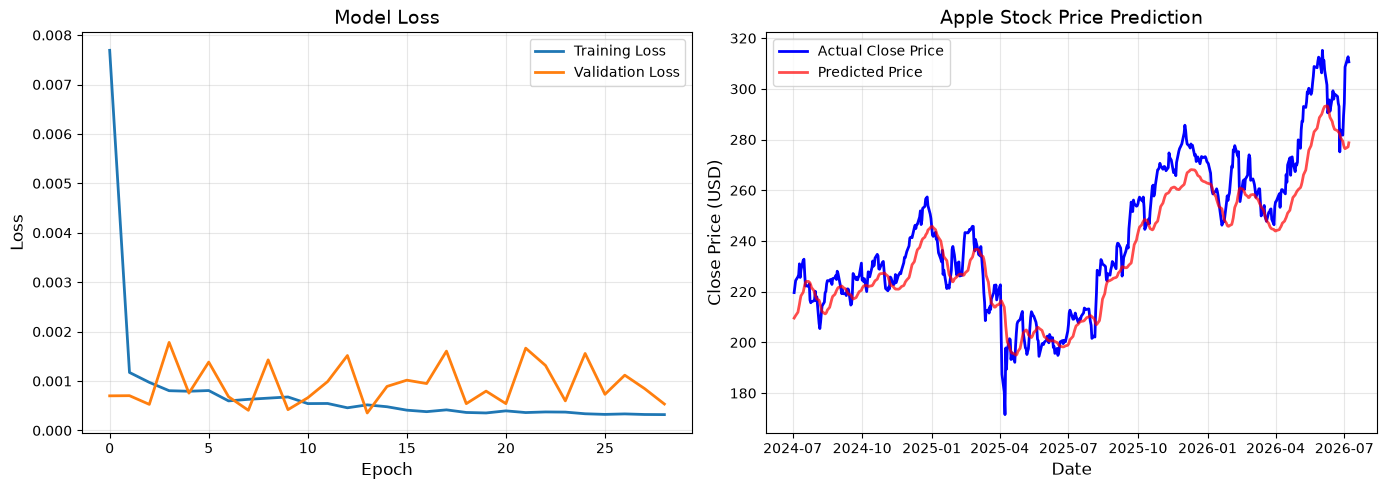

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].plot(history.history['loss'],label='Training Loss',linewidth=2)
axes[0].plot(history.history['val_loss'],label='Validation Loss',linewidth=2)
axes[0].set_title('Model Loss',fontsize=14)
axes[0].set_xlabel('Epoch',fontsize=12)
axes[0].set_ylabel('Loss',fontsize=12)
axes[0].legend()
axes[0].grid(True,alpha=0.3)


#Prediction vs Actual
# Calculate the start index based on the length difference
start_index = len(test_dates) - len(y_test_actual)

# Slice test_dates to match the prediction arrays
test_dates_aligned = test_dates[start_index:]

axes[1].plot(test_dates, y_test_actual, label='Actual Close Price', color='blue', linewidth=2)
axes[1].plot(test_dates, y_pred_actual, label='Predicted Price', color='red', linewidth=2, alpha=0.7)
axes[1].set_title('Apple Stock Price Prediction', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Close Price (USD)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Step14. Actual vs Predicted Scatter

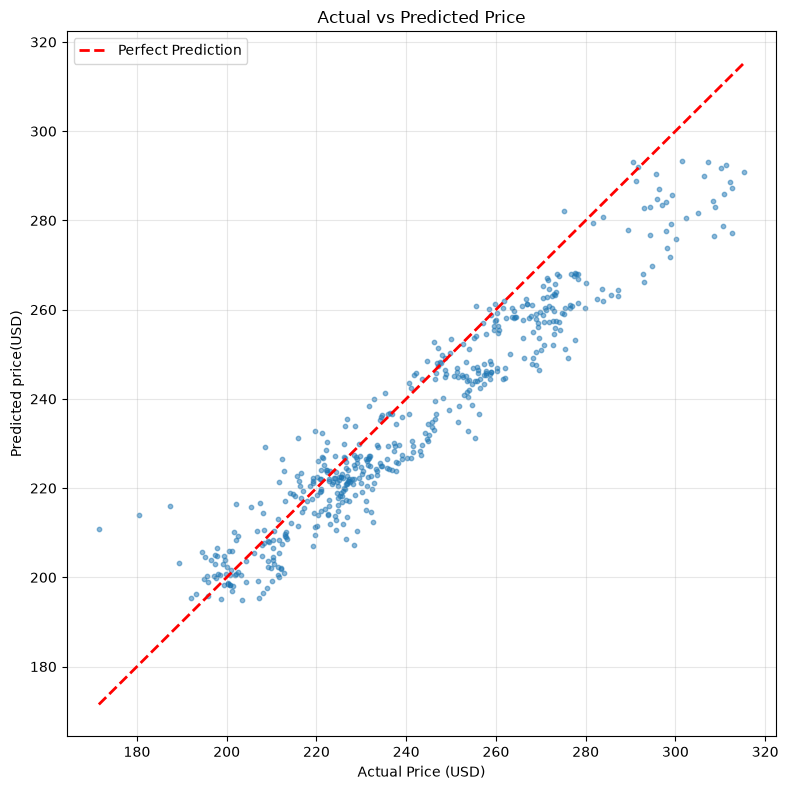

In [34]:
plt.figure(figsize=(8,8))
plt.scatter(y_test_actual,y_pred_actual,alpha=0.5,s=10)
min_val=min(y_test_actual.min(),y_pred_actual.min())
max_val=max(y_test_actual.max(),y_pred_actual.max())
plt.plot([min_val,max_val],[min_val,max_val],'r--',linewidth=2,label='Perfect Prediction')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted price(USD)')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()


Step15. Summary

In [32]:
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"RMSE: ${rmse:.2f}")
print(f"MAE: ${mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

Training samples: 1949
Test samples: 503
RMSE: $11.02
MAE: $8.72
R² Score: 0.8554
MAPE: 3.51%
